# 14 — Aspect breakdown with real aspect labels

The French track had to invent lexicons. This dataset ships **11 real aspect
assignments** at sentence level, so the hand-built matching in `src/aspects.py`
is replaced outright.

A caveat worth keeping in view: those assignments are also machine-made
(BERTopic plus cosine similarity). But *which topic a sentence is about* is a
far easier judgement than its sentiment, and 79% came from topic modelling
rather than the weaker cosine fallback — so they are used, with the method
stated.

In [1]:
import sys, json, time
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))
from src.normalize import normalize, NORMALIZE_VERSION
OUT = REPO / "data_en"
LABELS = ["negative", "neutral", "positive"]

import joblib
from src.predict import apply_temperature
from src.estimate import acc_prevalence_multiclass, confusion_matrix_rates

SRC = REPO / "dataset for training in ENGLISH" / "df_final_absa_v4.csv"
cfg = json.loads((REPO / "inference_config_en.json").read_text(encoding="utf-8"))
model = joblib.load(cfg["model_repo"])
T = cfg["temperature"]
ORDER = [cfg["class_order"].index(l) for l in LABELS]
M = np.array(cfg["confusion_matrix"])

en = pd.read_csv(SRC)
en = en[en.langue == "Anglais"].copy()
en["phrase"] = en.phrase.astype(str).map(normalize)
print(f"English sentences: {len(en):,}   aspects: {en.aspect_label.nunique()}")
print(f"assignment source: " + ", ".join(
    f"{k} {v/len(en):.0%}" for k, v in en.source_aspect.value_counts().items()))

English sentences: 32,625   aspects: 11
assignment source: bertopic 79%, cosine 21%


In [2]:
P = apply_temperature(model.decision_function(en.phrase)[:, ORDER], T)
en["pred"] = np.array(LABELS)[P.argmax(1)]
en["conf"] = P.max(1)
print(dict(en.pred.value_counts()))

{'positive': np.int64(15015), 'negative': np.int64(11798), 'neutral': np.int64(5812)}


## Per-aspect satisfaction, corrected

The §10 bias argument holds inside a subgroup just as much as overall, so the
same correction is applied per aspect.

In [3]:
rows = []
for asp, g in en.groupby("aspect_label"):
    if len(g) < 100:
        continue
    counts = np.array([(g.pred == l).mean() for l in LABELS])
    corr = acc_prevalence_multiclass(counts, M)
    rows.append({"aspect": asp, "sentences": len(g),
                 "count_pos": counts[2], "corrected_pos": corr[2],
                 "corrected_neg": corr[0],
                 "mean_star": g.note.mean()})
res = pd.DataFrame(rows).sort_values("corrected_pos")
print(f"{'aspect':<34} {'n':>6} {'count':>7} {'corrected':>10} {'neg':>7} {'avg star':>9}")
for _, r in res.iterrows():
    print(f"{r.aspect:<34} {r.sentences:>6,} {r.count_pos:>7.1%} "
          f"{r.corrected_pos:>10.1%} {r.corrected_neg:>7.1%} {r.mean_star:>9.2f}")

aspect                                  n   count  corrected     neg  avg star
Confort thermique / Température     1,068    7.9%       0.0%  100.0%      2.84
Bruit & Qualité du sommeil            846   13.4%       7.9%   92.1%      2.96
Rapport qualité-prix                  615   40.2%      29.5%    9.5%      3.49
Chambre & Propreté                 10,542   31.8%      34.1%   65.9%      3.24
Internet & Wi-Fi                      459   34.0%      38.6%   61.4%      3.26
Restauration                        3,792   48.7%      52.2%   21.6%      3.65
Service                             2,642   48.3%      54.5%   45.5%      3.50
Localisation                        4,500   61.5%      67.3%    0.0%      3.69
Équipements & Activités             2,096   56.5%      68.3%   22.3%      3.66
Personnel                           4,527   64.6%      75.2%   24.8%      3.75
Expérience & Valeur                 1,538   68.9%      78.4%   21.6%      4.01


### Sanity check

Average star rating is an independent human signal: an aspect our model scores
low should also appear in lower-rated reviews. If the two rankings disagree,
the aspect layer is not measuring what it claims to.

Spearman(corrected satisfaction, mean star rating) = 0.955  p=0.0000
positive and significant => the aspect scores track an independent signal


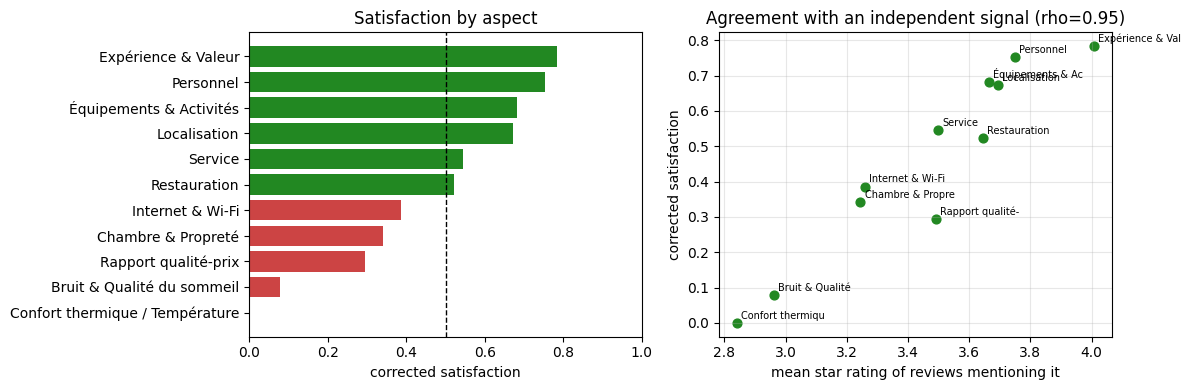

In [4]:
from scipy.stats import spearmanr
rho, pv = spearmanr(res.corrected_pos, res.mean_star)
print(f"Spearman(corrected satisfaction, mean star rating) = {rho:.3f}  p={pv:.4f}")
print("positive and significant => the aspect scores track an independent signal")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(res.aspect, res.corrected_pos,
             color=["#c44" if v < .5 else "#282" for v in res.corrected_pos])
axes[0].axvline(.5, color="k", ls="--", lw=1)
axes[0].set_xlabel("corrected satisfaction"); axes[0].set_xlim(0, 1)
axes[0].set_title("Satisfaction by aspect")
axes[1].scatter(res.mean_star, res.corrected_pos, s=40, color="#282")
for _, r in res.iterrows():
    axes[1].annotate(r.aspect[:16], (r.mean_star, r.corrected_pos), fontsize=7,
                     xytext=(3, 3), textcoords="offset points")
axes[1].set_xlabel("mean star rating of reviews mentioning it")
axes[1].set_ylabel("corrected satisfaction")
axes[1].set_title(f"Agreement with an independent signal (rho={rho:.2f})")
axes[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig(OUT / "fig_aspects.png", dpi=120); plt.show()

In [5]:
res.to_csv(OUT / "results_aspects.csv", index=False)
json.dump({"spearman_vs_star": round(float(rho), 4), "p_value": float(pv),
           "aspects": res.round(4).to_dict("records")},
          open(OUT / "results_aspects.json", "w"), indent=2, ensure_ascii=False)
print("worst aspect:", res.iloc[0].aspect, f"({res.iloc[0].corrected_pos:.1%})")
print("best  aspect:", res.iloc[-1].aspect, f"({res.iloc[-1].corrected_pos:.1%})")

worst aspect: Confort thermique / Température (0.0%)
best  aspect: Expérience & Valeur (78.4%)
